In [26]:
# package import
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW2')
import pandas as pd

# 读数据
train = pd.read_csv("BreastCancer_train.csv")
test = pd.read_csv("BreastCancer_test.csv")

# 删除缺失值
train = train.dropna()
test = test.dropna()

# 查看列名
print(test.columns.tolist())
print(train.columns.tolist())

print(train.head(10))


['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Class']
['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Class']
        Id  Cl.thickness  Cell.size  Cell.shape  Marg.adhesion  Epith.c.size  \
0   831268             1          1           1              1             1   
1  1269574             4          1           1              1             2   
2   814265             2          1           1              1             2   
3  1227244             1          1           1              1             2   
4   822829             8         10          10             10             6   
5  1174057             4          2           1              1             2   
6   809912            10          3           3              1             2   
7  1180831             3          1           1         

In [27]:
# 把 "Class" 转成 0/1
print(train['Class'].unique())  # 查看可能的值

# 转换
train['Class'] = train['Class'].map({'benign': 0, 'malignant': 1})
test['Class'] = test['Class'].map({'benign': 0, 'malignant': 1})

# 全部特征（去掉 ID 和 Class）
X_train_full = train.drop(columns=['Id', 'Class'])
y_train = train['Class']

X_test_full = test.drop(columns=['Id', 'Class'])
y_test = test['Class']

# 5个特征
selected_features = ['Cl.thickness', 'Cell.shape', 'Marg.adhesion', 'Bare.nuclei', 'Bl.cromatin']
X_train_5 = X_train_full[selected_features]
X_test_5 = X_test_full[selected_features]

['benign' 'malignant']


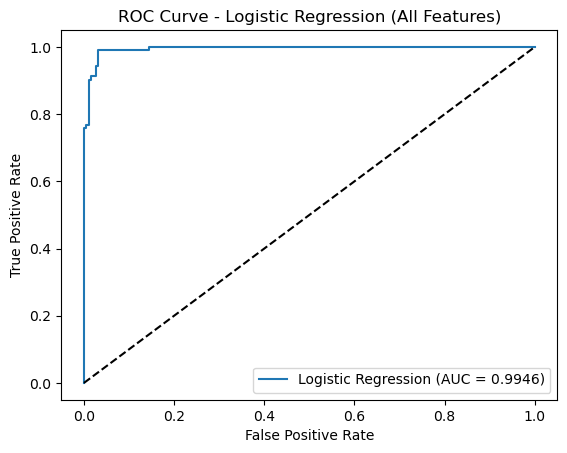

LR_AUC (Full Features): 0.9946292088411485


In [28]:
##P2_Q1
# 全部特征
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 训练（用全部特征）
lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(X_train_full, y_train)

# 预测概率（注意：要预测'malignant': 1就是label = 1的概率）
y_prob_full = lr_full.predict_proba(X_test_full)[:, 1] #取所有行第一列 label = 1

# 画 ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_full)
lr_roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (All Features)')
plt.legend()
plt.show()

print("LR_AUC (Full Features):", lr_roc_auc)

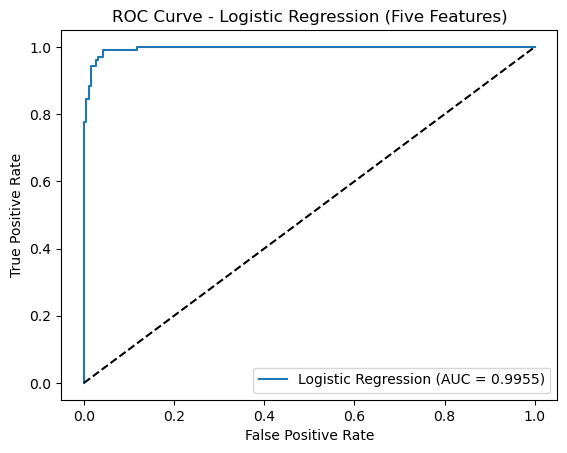

LR_AUC (Five Features): 0.99550712662673


In [29]:
##P2_Q2
# 五个特征
# 训练
lr_five = LogisticRegression(max_iter=1000)
lr_five.fit(X_train_5, y_train)

# 预测概率
y_prob_five = lr_five.predict_proba(X_test_5)[:, 1]

# 画 ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_five)
lr5_roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr5_roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Five Features)')
plt.legend()
plt.show()

print("LR_AUC (Five Features):", lr5_roc_auc)

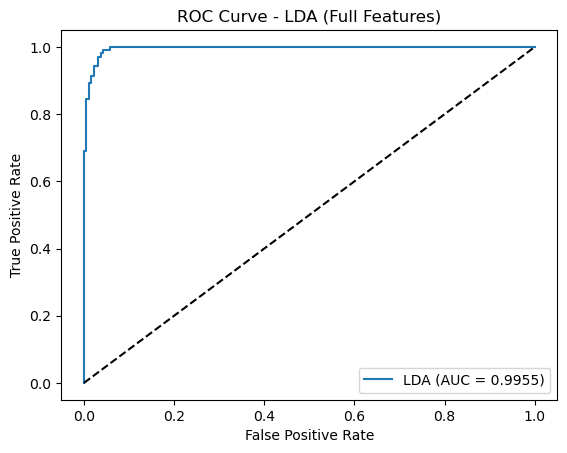

LDA_AUC (Full Features): 0.9954554844040487


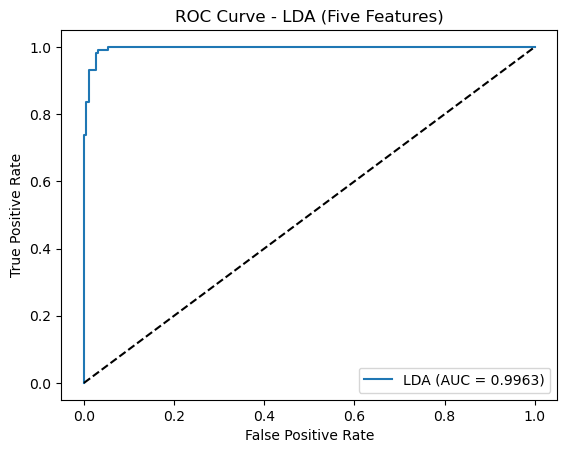

LDA_AUC (Five Features): 0.9963334021896302


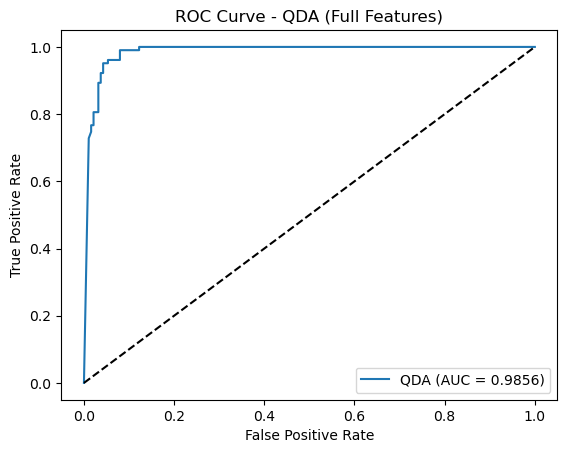

QDA_AUC (Full Features): 0.9855918198719273


In [30]:
# P2_Q3-Q5
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# LDA 全部特征
lda_full = LinearDiscriminantAnalysis()
lda_full.fit(X_train_full, y_train)
y_prob_lda_full = lda_full.predict_proba(X_test_full)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_lda_full)
lda_roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'LDA (AUC = {lda_roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LDA (Full Features)')
plt.legend()
plt.show()

print("LDA_AUC (Full Features):", lda_roc_auc)

# LDA 5个特征
lda_five = LinearDiscriminantAnalysis()
lda_five.fit(X_train_5, y_train)
y_prob_lda_five = lda_five.predict_proba(X_test_5)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_lda_five)
lda5_roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'LDA (AUC = {lda5_roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LDA (Five Features)')
plt.legend()
plt.show()

print("LDA_AUC (Five Features):", lda5_roc_auc)


# QDA - 全部特征
qda_full = QuadraticDiscriminantAnalysis()
qda_full.fit(X_train_full, y_train)
y_prob_qda = qda_full.predict_proba(X_test_full)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_qda)
qda_roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'QDA (AUC = {qda_roc_auc :.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - QDA (Full Features)')
plt.legend()
plt.show()

print("QDA_AUC (Full Features):", qda_roc_auc)

In [31]:
# P2_Q6
results = []

results.append({"Model": "logistic regression", "Features": "All", "AUC": lr_roc_auc})
results.append({"Model": "logistic regression", "Features": "Five", "AUC": lr5_roc_auc})
results.append({"Model": "LDA", "Features": "All", "AUC": lda_roc_auc})
results.append({"Model": "LDA", "Features": "Five", "AUC": lda5_roc_auc})
results.append({"Model": "QDA", "Features": "All", "AUC": qda_roc_auc})

# 构建表格
df_auc = pd.DataFrame(results)

# 按 AUC 从高到低排序
df_auc = df_auc.sort_values(by="AUC", ascending=False).reset_index(drop=True)

# 打印表格（保留3位小数）
print(df_auc.round(6))

                 Model Features       AUC
0                  LDA     Five  0.996333
1  logistic regression     Five  0.995507
2                  LDA      All  0.995455
3  logistic regression      All  0.994629
4                  QDA      All  0.985592
